# Part 1 — Foundations & Data Handling

**Series:** *Time Series Analysis in Python — from Statistical Modeling to Machine Learning*

This is the first notebook in a progressive series that moves from classical
statistics through modern deep learning. Part 1 is the groundwork: it will not
forecast anything yet. Instead it builds the two skills every later part
depends on — **thinking about a series in terms of its components**, and
**handling time-indexed data correctly in pandas**. Get these wrong and every
model downstream inherits the mistake.

### What you will learn
1. What a time series is, and the four components we decompose one into
2. How to turn raw rows into a proper `DatetimeIndex` with an explicit frequency
3. Selecting and slicing data by time
4. Resampling — changing the frequency of a series up or down
5. Rolling / expanding windows and lag / shift operations
6. Detecting and repairing missing timestamps and gaps
7. The core diagnostic plots for time series
8. Making the components concrete with an STL decomposition

### The dataset
Throughout this series we use a single real monthly dataset,
`monthly_price.csv`: **356 months of global commodity prices, from January 1992
to August 2021**. It mixes three families of series, which lets us contrast
different temporal behaviours:

| Group | Columns | Character |
|-------|---------|-----------|
| Fertilizers | `Urea_Price`, `MP_Price`, `TSP_Price` | Strong trends, supply-driven spikes |
| Crops | `Maize_Price`, `Rice_Price`, `Wheat_Price` | Seasonality + trend |
| Market indices | `Food_Price_Index`, `Energy_Price_Index`, `VIX_Index` | Macro cycles; VIX is volatility, not a price |

The dataset sits in the health / environment / agriculture / finance space and
carries genuine macro events — the 2008 food-price crisis, the 2008 financial
crisis (visible in the VIX), and the 2020 COVID shock — so the plots tell a real
story rather than a synthetic one.


## 0. Setup

We keep Part 1 deliberately lean on libraries — `pandas`, `numpy`, and
`matplotlib` do almost all the work, with a single `statsmodels` call at the end
for decomposition. Everything here is standard scientific-Python.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Consistent, readable plot styling for the whole notebook
plt.rcParams.update({
    "figure.figsize": (11, 4.2),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "font.size": 11,
    "lines.linewidth": 1.6,
})

# A small reusable colour palette
PALETTE = ["#2b6cb0", "#c05621", "#2f855a", "#6b46c1", "#b83280", "#718096"]

print("pandas :", pd.__version__)
print("numpy  :", np.__version__)

pandas : 3.0.2
numpy  : 2.4.4


## 1. What is a time series?

A **time series** is a sequence of observations recorded in time order, usually
at a fixed spacing (here, one observation per month). That ordering is the whole
point: unlike a normal tabular dataset, **the rows are not exchangeable**. You
cannot shuffle them, and when you validate a model you cannot let information
from the future leak into the past. Almost every rule that makes time series
special follows from that one fact.

**Univariate vs. multivariate.** A univariate series tracks one quantity over
time (e.g. `Urea_Price` alone). A multivariate series tracks several aligned on
the same time index (all nine columns together). Our file is multivariate, which
lets us study each series on its own *and* the relationships between them.

**The four components.** The classical way to reason about a series is to imagine
it as a sum (or product) of parts:

- **Trend (T)** — the long-run direction (fertilizer prices drifting up over 30 years).
- **Seasonality (S)** — a pattern that repeats over a *fixed, known* period (a 12-month crop cycle).
- **Cyclicity (C)** — longer swings with *no fixed* period, tied to the economy (boom/bust). Often folded into the trend in practice.
- **Residual / noise (R)** — what is left after removing the above; the irregular part.

We write either an **additive** model, $y_t = T_t + S_t + R_t$, when the size of
the seasonal swing is roughly constant, or a **multiplicative** model,
$y_t = T_t \times S_t \times R_t$, when the swing grows with the level of the
series. We will separate these components explicitly in Section 8.

## 2. Loading the data and building a proper time index

Read the raw file first and look at it before doing anything clever.

In [2]:
raw = pd.read_csv("monthly_price.csv")
print("shape:", raw.shape)
raw.head()

shape: (356, 13)


,ID,YEAR,MONTH,TIME,Urea_Price,MP_Price,TSP_Price,Maize_Price,Rice_Price,Wheat_Price,Food_Price_Index,Energy_Price_Index,VIX_Index
0,1,1992,Jan,Jan-92,122.5,110.0,120.0,109.3,277.3,170.0,55.7,23.7,17.7
1,2,1992,Feb,Feb-92,120.6,110.0,120.0,113.6,278.3,177.1,55.5,23.8,17.5
2,3,1992,Mar,Mar-92,120.0,110.0,120.0,117.0,277.2,169.4,55.6,23.8,17.5
3,4,1992,Apr,Apr-92,120.0,110.0,120.2,108.5,278.0,159.9,54.1,25.2,16.6
4,5,1992,May,May-92,120.0,110.0,120.5,109.6,274.0,149.7,54.2,26.3,15.1


In [3]:
raw.dtypes

ID                      int64
YEAR                    int64
MONTH                     str
TIME                      str
Urea_Price            float64
MP_Price              float64
TSP_Price             float64
Maize_Price           float64
Rice_Price            float64
Wheat_Price           float64
Food_Price_Index      float64
Energy_Price_Index    float64
VIX_Index             float64
dtype: object

Two things stand out. First, there are **no missing values** (we will confirm
this), which is unusual and convenient — so later we will *deliberately* punch
holes in a copy to practise repairing them. Second, there is already a `TIME`
column, but look closely at it:

In [4]:
print("early TIME values:", raw["TIME"].head(3).tolist())
print("late  TIME values:", raw["TIME"].tail(3).tolist())

early TIME values: ['Jan-92', 'Feb-92', 'Mar-92']
late  TIME values: ['21-Jun', '21-Jul', '21-Aug']


The format is **inconsistent** — `Jan-92` early on, `21-Apr` later. Parsing that
string directly is a trap. This is a common real-world lesson: **don't trust a
pre-baked date string; rebuild the index from reliable parts.** The `YEAR`
(integer) and `MONTH` (three-letter abbreviation) columns are clean, so we
construct the timestamp from those instead.

In [5]:
# Build a first-of-month timestamp from YEAR + MONTH, which are reliable.
dates = pd.to_datetime(
    raw["YEAR"].astype(str) + "-" + raw["MONTH"],
    format="%Y-%b",   # e.g. "1992-Jan"
)

df = raw.drop(columns=["ID", "YEAR", "MONTH", "TIME"]).copy()
df.index = dates
df.index.name = "date"

# Tell pandas the spacing is 'month start' (MS). This is the crucial step.
df = df.asfreq("MS")

df.head()

,Urea_Price,MP_Price,TSP_Price,Maize_Price,Rice_Price,Wheat_Price,Food_Price_Index,Energy_Price_Index,VIX_Index
date,,,,,,,,,
1992-01-01,122.5,110.0,120.0,109.3,277.3,170.0,55.7,23.7,17.7
1992-02-01,120.6,110.0,120.0,113.6,278.3,177.1,55.5,23.8,17.5
1992-03-01,120.0,110.0,120.0,117.0,277.2,169.4,55.6,23.8,17.5
1992-04-01,120.0,110.0,120.2,108.5,278.0,159.9,54.1,25.2,16.6
1992-05-01,120.0,110.0,120.5,109.6,274.0,149.7,54.2,26.3,15.1


### Why `asfreq("MS")` matters

Setting an explicit **frequency** on the index is not cosmetic. It records the
*contract* that observations are spaced one month apart, starting on the first of
each month. With a frequency set, pandas and statsmodels can reason about the
calendar: they know how many periods a year holds, can generate future dates, and
will surface a gap as a missing timestamp rather than silently skipping it.

In [6]:
print("index dtype :", df.index.dtype)
print("frequency    :", df.index.freq)
print("n periods    :", len(df))
print("span         :", df.index.min().date(), "->", df.index.max().date())
print("is monotonic :", df.index.is_monotonic_increasing)
print("any missing? :", df.isna().any().any())

index dtype : datetime64[us]
frequency    : <MonthBegin>
n periods    : 356
span         : 1992-01-01 -> 2021-08-01
is monotonic : True
any missing? : False


A few useful properties are now available directly off the `DatetimeIndex`.
These `.dt`-style accessors (here used on the index itself) are the raw material
for the calendar features we will engineer in later parts.

In [7]:
idx_info = pd.DataFrame({
    "year":    df.index.year,
    "month":   df.index.month,
    "quarter": df.index.quarter,
    "month_name": df.index.month_name(),
}, index=df.index)
idx_info.head()

,year,month,quarter,month_name
date,,,,
1992-01-01,1992,1,1,January
1992-02-01,1992,2,1,February
1992-03-01,1992,3,1,March
1992-04-01,1992,4,2,April
1992-05-01,1992,5,2,May


### A note on time zones

Our index is **time-zone naive**, and for monthly economic data that is exactly
right — a monthly price has no meaningful hour, let alone a UTC offset. Time
zones matter when you work with sub-daily data collected across regions (sensor
feeds, web logs, market ticks). The mechanics, for reference:

In [8]:
# Localize to a zone, then convert — shown for reference only.
sample = df.index[:3]
localized = sample.tz_localize("UTC")
converted = localized.tz_convert("America/New_York")
for a, b in zip(localized, converted):
    print(a, " -> ", b)
print("\nOur working index stays tz-naive (correct for monthly data):", df.index.tz)

1992-01-01 00:00:00+00:00  ->  1991-12-31 19:00:00-05:00
1992-02-01 00:00:00+00:00  ->  1992-01-31 19:00:00-05:00
1992-03-01 00:00:00+00:00  ->  1992-02-29 19:00:00-05:00

Our working index stays tz-naive (correct for monthly data): None


## 3. Selecting and slicing by time

Once the index is a `DatetimeIndex`, time-based selection becomes very natural.
**Partial-string indexing** lets you name a year or a month and pandas expands it
to the full range.

In [9]:
# One full year
df.loc["2008"].head()

,Urea_Price,MP_Price,TSP_Price,Maize_Price,Rice_Price,Wheat_Price,Food_Price_Index,Energy_Price_Index,VIX_Index
date,,,,,,,,,
2008-01-01,376.6,230.6,539.2,206.7,375.6,336.1,106.2,118.0,25.8
2008-02-01,328.1,240.0,729.4,220.1,464.8,393.9,116.1,123.6,25.5
2008-03-01,371.0,240.0,875.6,234.4,594.0,403.8,123.9,133.3,27.1
2008-04-01,462.5,393.0,1029.0,246.4,907.0,326.9,127.6,142.5,21.6
2008-05-01,633.8,546.0,1037.0,243.5,901.8,288.4,127.3,159.4,18.3


In [10]:
# A closed date range (both endpoints included), a subset of columns
df.loc["2007-06":"2008-12", ["Food_Price_Index", "Energy_Price_Index"]].head()

,Food_Price_Index,Energy_Price_Index
date,,
2007-06-01,81.5,90.0
2007-07-01,83.4,94.8
2007-08-01,84.7,91.2
2007-09-01,89.4,98.3
2007-10-01,92.8,105.4


In [11]:
# A single month
df.loc["2020-04", ["Maize_Price", "Rice_Price", "Wheat_Price"]]

,Maize_Price,Rice_Price,Wheat_Price
date,,,
2020-04-01,146.9,564.0,179.8


Because the index is sorted and typed, these lookups are fast and read almost
like English. Contrast that with filtering a plain string column, which forces a
full scan and breaks the moment the string format drifts — exactly the problem we
sidestepped in Section 2.

## 4. Resampling — changing the frequency

**Resampling** converts a series from one frequency to another. It comes in two
directions:

- **Downsampling** — to a *coarser* frequency (monthly → quarterly → yearly). You
  are combining many periods into one, so you must **aggregate** (mean, sum, last, …).
- **Upsampling** — to a *finer* frequency (monthly → weekly). You are creating new
  timestamps that have no data yet, so you must **fill or interpolate** them.

The API is `df.resample(rule).aggregation()`. The `rule` uses offset aliases:
`MS` month-start, `QE` quarter-end, `YE` year-end, `W` weekly, `D` daily.

In [12]:
# Downsample to yearly averages (a smoother view of the trend)
yearly = df.resample("YE").mean()
yearly[["Urea_Price", "Food_Price_Index", "VIX_Index"]].head()

,Urea_Price,Food_Price_Index,VIX_Index
date,,,
1992-12-31,117.608333,53.875,15.458333
1993-12-31,85.541667,54.125,12.691667
1994-12-31,93.883333,58.150,13.950000
1995-12-31,126.866667,63.000,12.391667
1996-12-31,153.691667,67.975,16.466667


The aggregation you choose encodes a decision about *meaning*. For a **price**,
the yearly **mean** or **last** value is sensible. For a **flow** such as rainfall
or sales you would **sum**. For volatility like the VIX you might take the
**max** to capture the worst of the year. Resampling is never just mechanical.

In [13]:
# Different aggregations answer different questions
agg = df["VIX_Index"].resample("YE").agg(["mean", "max", "min", "std"]).round(1)
agg.head()

,mean,max,min,std
date,,,,
1992-12-31,15.5,17.7,12.2,1.9
1993-12-31,12.7,14.1,11.4,0.9
1994-12-31,14.0,16.5,11.3,1.7
1995-12-31,12.4,14.4,11.5,0.7
1996-12-31,16.5,19.3,13.5,1.5


In [14]:
# Upsample monthly -> weekly. New weekly slots start empty and must be filled.
wk = df["Food_Price_Index"].resample("W").asfreq()   # no fill: creates NaNs
print("weekly slots:", len(wk), " of which missing:", int(wk.isna().sum()))

wk_ffill  = df["Food_Price_Index"].resample("W").ffill()          # carry last value
wk_interp = df["Food_Price_Index"].resample("W").interpolate("linear")  # straight line

compare = pd.DataFrame({"as_is": wk, "ffill": wk_ffill, "interp": wk_interp})
compare.head(8)

weekly slots: 1544  of which missing: 1493


,as_is,ffill,interp
date,,,
1992-01-05,NaN,55.7,55.66
1992-01-12,NaN,55.7,55.62
1992-01-19,NaN,55.7,55.58
1992-01-26,NaN,55.7,55.54
1992-02-02,NaN,55.5,55.52
1992-02-09,NaN,55.5,55.54
1992-02-16,NaN,55.5,55.56
1992-02-23,NaN,55.5,55.58


`asfreq()` vs `resample()`: `asfreq()` just *changes the labels* and shows you
the holes; `resample()` is the general engine that also aggregates or fills. Use
`asfreq()` when you only want to relabel or expose gaps, `resample()` for
everything else.

## 5. Rolling windows, expanding windows, and lags

These three operations appear constantly — first as diagnostics, and later
(Part 7) as engineered **features** for machine-learning models.

- **Rolling window** — a fixed-width window that slides along the series; e.g. a
  12-month rolling mean is a smoothed trend.
- **Expanding window** — an *anchored* window that grows to include everything up
  to the current point; e.g. the cumulative-to-date average.
- **Shift / lag** — move the series forward or backward in time; the basis of
  growth rates and of the lag features every autoregressive model relies on.

In [15]:
s = df["Urea_Price"]

feat = pd.DataFrame({
    "value":        s,
    "roll_mean_12": s.rolling(window=12).mean(),   # 12-month smoothed trend
    "roll_std_12":  s.rolling(window=12).std(),    # rolling volatility
    "expanding_mean": s.expanding().mean(),        # cumulative average to date
})
feat.loc["2007":"2008"].head(8).round(1)

,value,roll_mean_12,roll_std_12,expanding_mean
date,,,,
2007-01-01,265.0,227.4,20.0,126.7
2007-02-01,299.4,234.5,28.3,127.6
2007-03-01,318.1,240.7,37.2,128.7
2007-04-01,291.0,244.4,40.0,129.6
2007-05-01,293.1,249.7,42.0,130.4
2007-06-01,291.9,256.5,41.6,131.3
2007-07-01,269.5,261.8,38.4,132.0
2007-08-01,260.6,266.0,34.9,132.7


Notice the first 11 rolling values would be `NaN` — a window of 12 cannot be
computed until 12 observations exist. That edge effect is expected; the choice is
whether to accept the shorter usable series or to `min_periods` your way around
it.

**Shifting** moves data relative to its timestamps. `shift(1)` pushes values one
month into the future (yesterday's value sitting on today's row) — precisely what
you need to compute change, and precisely the mechanism behind a *lag feature*.

In [16]:
growth = pd.DataFrame({
    "value":       s,
    "lag_1":       s.shift(1),                 # previous month's value
    "mom_change":  s.diff(1),                  # first difference: value - lag_1
    "mom_pct":     s.pct_change() * 100,       # month-over-month % change
    "yoy_pct":     s.pct_change(12) * 100,     # year-over-year % change (seasonal lag)
})
growth.loc["2008-06":"2008-12"].round(2)

,value,lag_1,mom_change,mom_pct,yoy_pct
date,,,,,
2008-06-01,642.0,633.8,8.2,1.29,119.94
2008-07-01,733.8,642.0,91.8,14.30,172.28
2008-08-01,785.0,733.8,51.2,6.98,201.23
2008-09-01,744.5,785.0,-40.5,-5.16,144.10
2008-10-01,575.0,744.5,-169.5,-22.77,77.58
2008-11-01,287.5,575.0,-287.5,-50.00,-21.51
2008-12-01,240.0,287.5,-47.5,-16.52,-40.25


**Differencing** (`.diff()`) — subtracting the previous value — is worth
flagging now because it returns in Part 2 as the standard tool for removing a
trend and making a series *stationary*. Here it simply gives month-over-month
change; there it becomes a modelling step.

## 6. Missing timestamps, gaps, and interpolation

Real series arrive with holes: a sensor drops out, a month goes unreported, a
source changes format. There are two very different kinds of "missing":

1. **A missing *value*** — the timestamp exists in the index but the number is `NaN`.
2. **A missing *timestamp*** — an entire period is absent from the index, so
   nothing even signals that it is gone.

The second is the dangerous one, because naive code steps right over it. A
frequency-aware index is your defence. Our data is complete, so to *practise* we
first create a damaged copy.

In [17]:
# Make a damaged copy: drop three specific months entirely (missing timestamps)
# and blank out a couple of values (missing values).
damaged = df["Food_Price_Index"].copy()

drop_months = pd.to_datetime(["2010-03-01", "2010-04-01", "2015-08-01"])
damaged = damaged.drop(index=drop_months)          # remove timestamps
damaged.loc["2012-07-01"] = np.nan                 # blank a value
damaged.loc["2018-11-01"] = np.nan

print("original length:", len(df), " damaged length:", len(damaged))
print("damaged freq   :", damaged.index.freq, "  <- lost, because rows were dropped")

original length: 356  damaged length: 353
damaged freq   : None   <- lost, because rows were dropped


Dropping rows silently destroyed the frequency. The fix is to **reindex onto the
complete expected calendar**, which re-inserts the absent months as explicit
`NaN`s — turning invisible missing *timestamps* into visible missing *values* we
can then treat.

In [18]:
full_index = pd.date_range(damaged.index.min(),
                           damaged.index.max(), freq="MS")
restored = damaged.reindex(full_index)
restored.index.name = "date"

missing = restored[restored.isna()]
print("re-inserted / blank periods now visible:")
print(missing)

re-inserted / blank periods now visible:
date
2010-03-01   NaN
2010-04-01   NaN
2012-07-01   NaN
2015-08-01   NaN
2018-11-01   NaN
Name: Food_Price_Index, dtype: float64


With the gaps exposed as `NaN`, we can choose how to fill them. The options are
not interchangeable — each encodes an assumption:

- **`ffill` / `bfill`** — carry the last (or next) known value. Assumes the series
  holds flat between observations. Fine for slow, step-like data; wrong for
  anything trending.
- **`interpolate("linear")`** — draw a straight line across the gap by position.
- **`interpolate("time")`** — like linear but weighted by the actual *time*
  distance, so it respects uneven gaps. Usually the right default for a
  time-indexed series.
- **`interpolate("spline"/"polynomial")`** — smooth curves; powerful but can
  overshoot, so use with care.

In [19]:
filled = pd.DataFrame({
    "damaged":  restored,
    "ffill":    restored.ffill(),
    "linear":   restored.interpolate("linear"),
    "time":     restored.interpolate("time"),
})
# Show the neighbourhood of the first dropped gap (2010-03 / 2010-04)
filled.loc["2010-01":"2010-06"].round(2)

,damaged,ffill,linear,time
date,,,,
2010-01-01,98.5,98.5,98.50,98.50
2010-02-01,95.4,95.4,95.40,95.40
2010-03-01,NaN,95.4,93.73,93.83
2010-04-01,NaN,95.4,92.07,92.09
2010-05-01,90.4,90.4,90.40,90.40
2010-06-01,89.1,89.1,89.10,89.10


Let's *see* the difference the method makes across that gap.

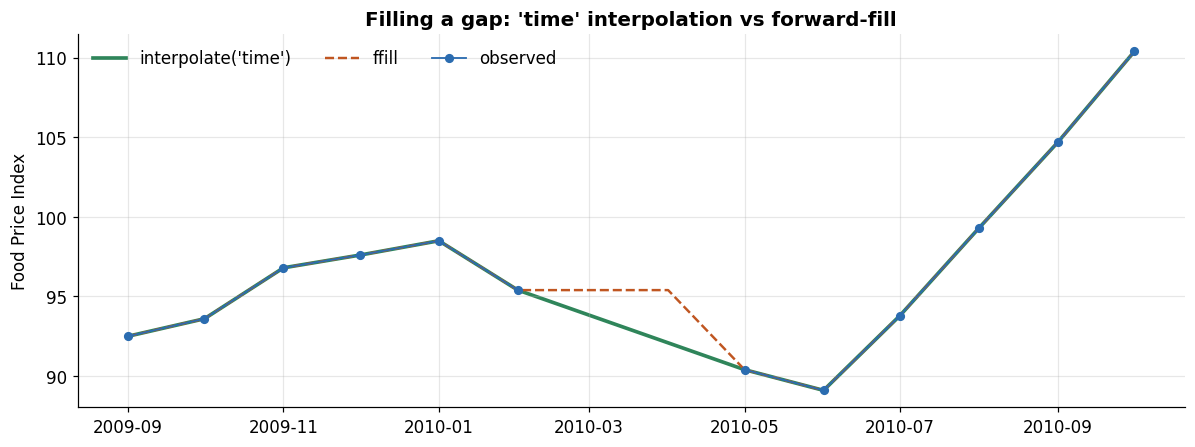

In [20]:
fig, ax = plt.subplots()
window = slice("2009-09", "2010-10")
ax.plot(filled.loc[window, "time"],  color=PALETTE[2], lw=2.4,
        label="interpolate('time')", zorder=1)
ax.plot(filled.loc[window, "ffill"], color=PALETTE[1], lw=1.6, ls="--",
        label="ffill", zorder=2)
ax.plot(filled.loc[window, "damaged"], color=PALETTE[0], marker="o", ms=5,
        lw=1.2, label="observed", zorder=3)
ax.set_title("Filling a gap: 'time' interpolation vs forward-fill")
ax.set_ylabel("Food Price Index")
ax.legend(frameon=False, ncol=3)
plt.tight_layout(); plt.show()

Forward-fill produces a flat shelf across March–April 2010; time interpolation
bridges the gap along the local trend. Neither *recovers* the truth — the honest
takeaway is that **imputation is an assumption, and you should record which one
you made** rather than pretend the gap was never there.

> **Irregular sampling.** Some series aren't merely missing a period here and
> there — they're recorded at genuinely uneven times (event logs, clinical
> visits). The same reindex-then-interpolate pattern applies: build the regular
> grid you *want*, reindex onto it, interpolate by `"time"`. From here on we
> return to the complete original `df`.

## 7. Visualization — the diagnostic toolkit

Before any modelling, *look at the data*. A handful of standard plots answers the
questions that decide everything downstream: is there a trend? a seasonal cycle?
changing variance? outliers or breaks?

### 7.1 Line plots — the first look

Plotting raw prices together is misleading because the series live on different
scales (TSP peaks above 1100; the VIX sits near 20). Two honest fixes: give a
couple of series their own axis, or **index everything to a common base** so you
compare *relative* movement.

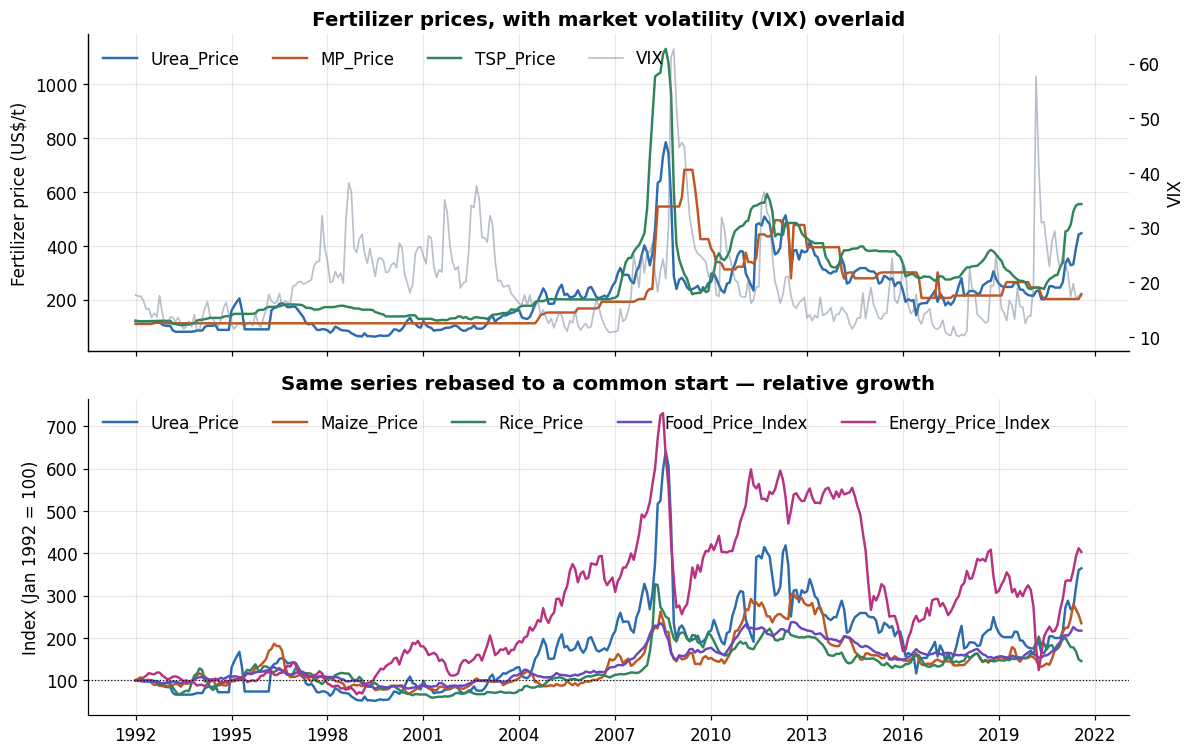

In [21]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Top: fertilizers on the left axis, VIX on a twin right axis
for col, c in zip(["Urea_Price", "MP_Price", "TSP_Price"], PALETTE):
    ax1.plot(df.index, df[col], color=c, label=col)
ax1.set_ylabel("Fertilizer price (US$/t)")
ax1.set_title("Fertilizer prices, with market volatility (VIX) overlaid")
axb = ax1.twinx()
axb.plot(df.index, df["VIX_Index"], color=PALETTE[5], alpha=0.5, lw=1.1, label="VIX")
axb.set_ylabel("VIX"); axb.grid(False)
l1, la1 = ax1.get_legend_handles_labels(); l2, la2 = axb.get_legend_handles_labels()
ax1.legend(l1 + l2, la1 + la2, frameon=False, ncol=4, loc="upper left")

# Bottom: everything rebased to 100 at the series start (relative comparison)
rebased = df / df.iloc[0] * 100
for col, c in zip(["Urea_Price", "Maize_Price", "Rice_Price",
                   "Food_Price_Index", "Energy_Price_Index"], PALETTE):
    ax2.plot(rebased.index, rebased[col], color=c, label=col)
ax2.axhline(100, color="k", lw=0.8, ls=":")
ax2.set_ylabel("Index (Jan 1992 = 100)")
ax2.set_title("Same series rebased to a common start — relative growth")
ax2.legend(frameon=False, ncol=5, loc="upper left")
ax2.xaxis.set_major_locator(mdates.YearLocator(3))
plt.tight_layout(); plt.show()

Already the structure is visible: a broad upswing into the **2008** commodity
spike, the VIX spiking in the **2008 financial crisis**, and a sharp move at the
right edge in **2020–21**. These are *cyclical* macro events, not fixed seasonal
ones — the distinction from Section 1 made concrete.

### 7.2 Seasonal plot — is there a within-year cycle?

To see **seasonality**, overlay each year as its own line across the twelve
months. If the lines share a shape, there is a repeating annual pattern; if they
are just stacked at different heights, the variation is trend, not season.

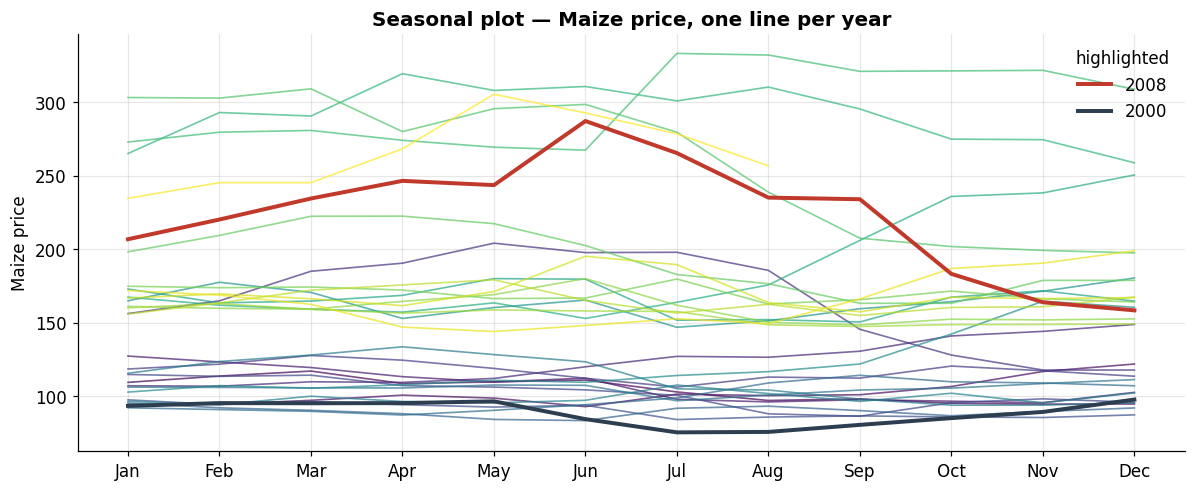

In [22]:
crop = df["Maize_Price"]
piv = pd.DataFrame({
    "year":  crop.index.year,
    "month": crop.index.month,
    "value": crop.values,
}).pivot(index="month", columns="year", values="value")

fig, ax = plt.subplots(figsize=(11, 4.6))
years = piv.columns
cmap = plt.cm.viridis(np.linspace(0, 1, len(years)))
for c, yr in zip(cmap, years):
    ax.plot(piv.index, piv[yr], color=c, lw=1.1, alpha=0.7)
# Emphasise a crisis year and a calm year
for yr, col, lw in [(2008, "#c0392b", 2.6), (2000, "#2c3e50", 2.6)]:
    if yr in piv.columns:
        ax.plot(piv.index, piv[yr], color=col, lw=lw, label=str(yr))
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_title("Seasonal plot — Maize price, one line per year")
ax.set_ylabel("Maize price"); ax.legend(frameon=False, title="highlighted")
plt.tight_layout(); plt.show()

The lines are separated mostly by *level* (that's trend, and the 2008 spike
stands far above the rest), while the within-year shape is comparatively muted —
maize here is trend-dominated with only modest seasonality. That is a genuine
finding: not every series has a strong season, and the seasonal plot is how you
check rather than assume.

### 7.3 Seasonal-subseries (month-wise) plot

A complementary view: group all observations by calendar month and show each
month's distribution. Flat month-to-month means little seasonality; a systematic
up-and-down across months means a seasonal cycle.

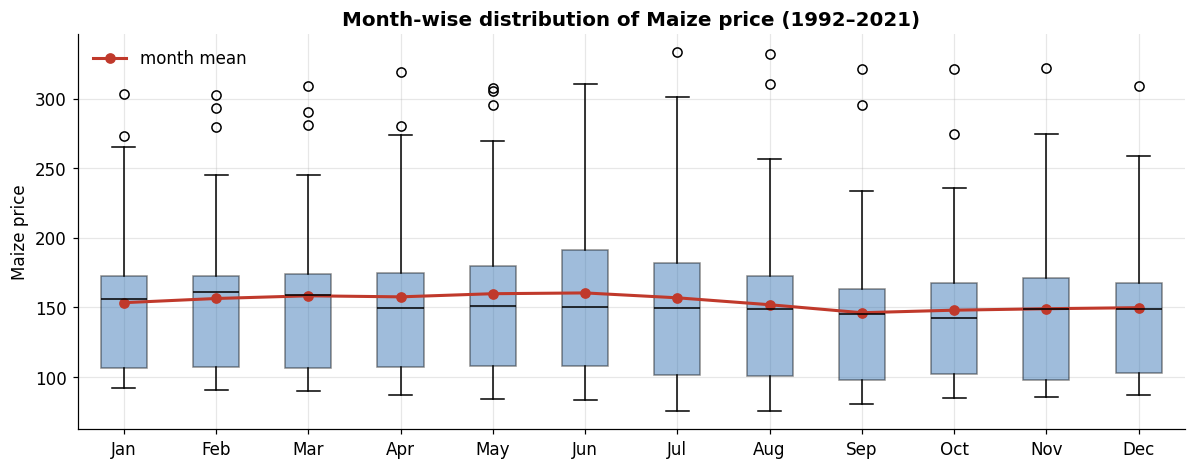

In [23]:
by_month = [crop[crop.index.month == m].values for m in range(1, 13)]
fig, ax = plt.subplots(figsize=(11, 4.4))
bp = ax.boxplot(by_month, tick_labels=["Jan","Feb","Mar","Apr","May","Jun",
                                       "Jul","Aug","Sep","Oct","Nov","Dec"],
                patch_artist=True, medianprops=dict(color="black"))
for patch in bp["boxes"]:
    patch.set_facecolor(PALETTE[0]); patch.set_alpha(0.45)
monthly_means = [np.mean(v) for v in by_month]
ax.plot(range(1, 13), monthly_means, color="#c0392b", marker="o", lw=2, label="month mean")
ax.set_title("Month-wise distribution of Maize price (1992–2021)")
ax.set_ylabel("Maize price"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

### 7.4 Lag plot and autocorrelation — a teaser for Part 2

A **lag plot** scatters each value against the value $k$ steps earlier. A tight
diagonal cloud means the series is highly *autocorrelated* — the present is
strongly predictable from the recent past, which is what makes forecasting
possible at all. This previews **autocorrelation (ACF)**, the backbone of Part 2.

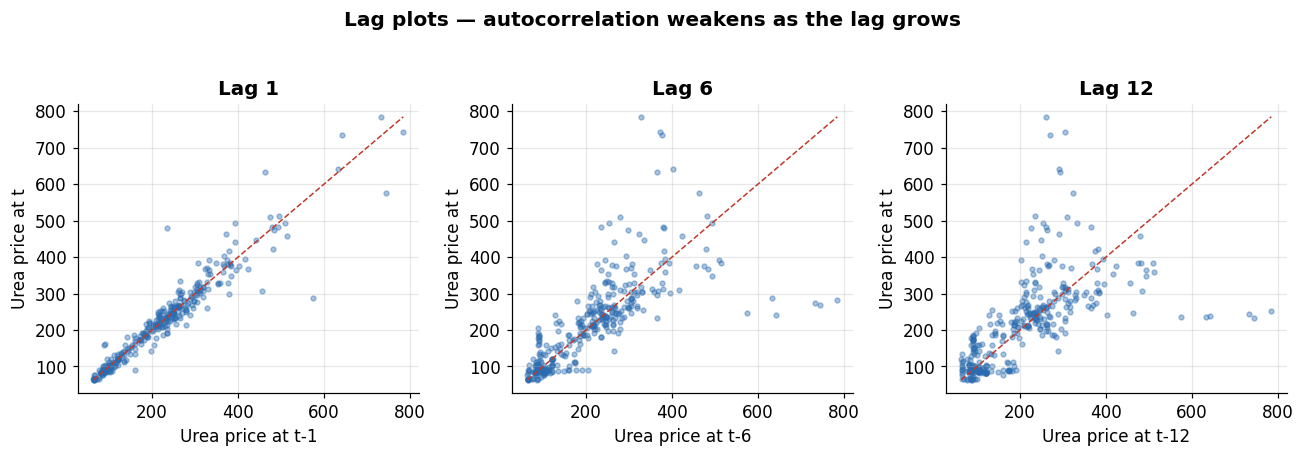

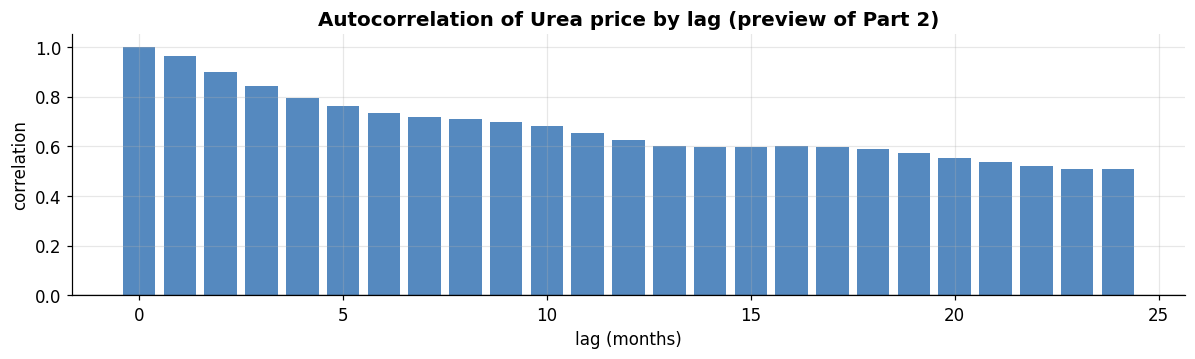

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, k in zip(axes, [1, 6, 12]):
    ax.scatter(s.shift(k), s, s=10, alpha=0.4, color=PALETTE[0])
    ax.set_xlabel(f"Urea price at t-{k}"); ax.set_ylabel("Urea price at t")
    ax.set_title(f"Lag {k}")
    lo, hi = s.min(), s.max()
    ax.plot([lo, hi], [lo, hi], color="#c0392b", lw=1, ls="--")
plt.suptitle("Lag plots — autocorrelation weakens as the lag grows",
             fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

# The same idea as a single number at each lag
acf_vals = [s.autocorr(lag=k) for k in range(0, 25)]
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(range(0, 25), acf_vals, color=PALETTE[0], alpha=0.8)
ax.axhline(0, color="k", lw=0.8)
ax.set_title("Autocorrelation of Urea price by lag (preview of Part 2)")
ax.set_xlabel("lag (months)"); ax.set_ylabel("correlation")
plt.tight_layout(); plt.show()

### 7.5 Calendar heatmap — year × month at a glance

A heatmap of year (rows) against month (columns) compresses the whole series into
one grid. Horizontal bands reveal trend (whole rows getting hotter over the
years); vertical structure would reveal seasonality (columns standing out).

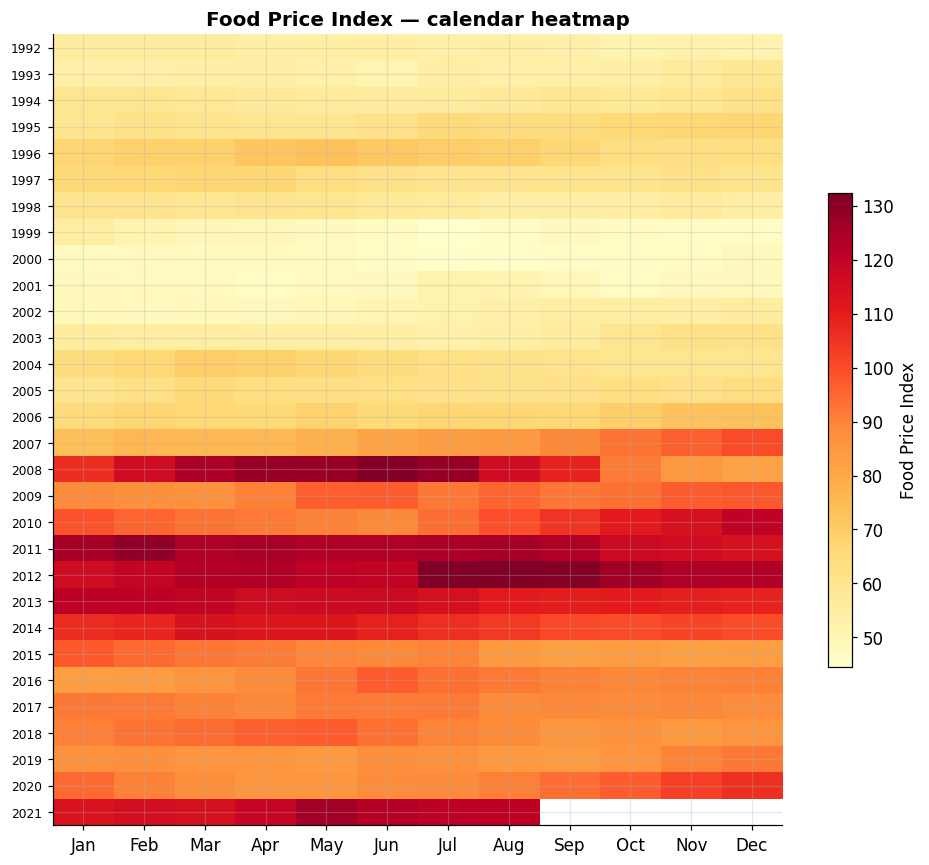

In [25]:
fpi = df["Food_Price_Index"]
grid = pd.DataFrame({
    "year":  fpi.index.year,
    "month": fpi.index.month,
    "value": fpi.values,
}).pivot(index="year", columns="month", values="value")

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(grid.values, aspect="auto", cmap="YlOrRd", origin="upper")
ax.set_xticks(range(12)); ax.set_xticklabels(
    ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_yticks(range(len(grid.index))); ax.set_yticklabels(grid.index, fontsize=8)
ax.set_title("Food Price Index — calendar heatmap")
cb = fig.colorbar(im, ax=ax, shrink=0.6); cb.set_label("Food Price Index")
plt.tight_layout(); plt.show()

The rows warm up dramatically around 2008 and again at the bottom (2020–21) —
the trend and the shocks jump out — while the columns are fairly uniform,
confirming the Food Price Index is driven by trend and macro cycles far more than
by month-of-year.

## 8. Making the components concrete — STL decomposition

Section 1 described the trend / seasonal / residual split conceptually. **STL**
(Seasonal-Trend decomposition using Loess) performs it numerically: it estimates
a smooth trend, a repeating seasonal component of a period you specify (12 for
monthly data), and leaves the residual. This is the one place in Part 1 we call
`statsmodels`, and it ties the whole notebook together — index, frequency, and
components in a single picture.

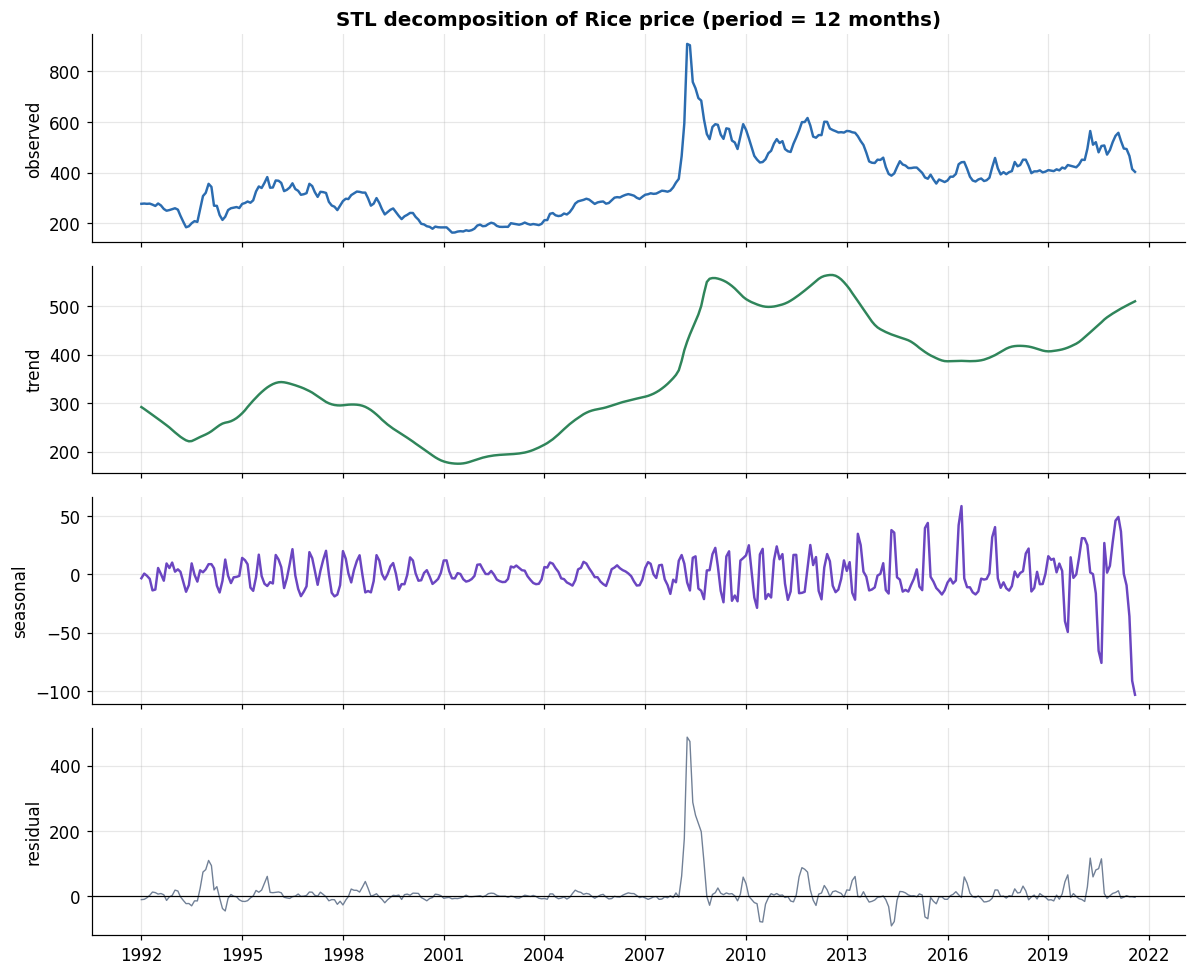

In [26]:
from statsmodels.tsa.seasonal import STL

series = df["Rice_Price"]            # a crop series with visible structure
stl = STL(series, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(series.index, series.values, color=PALETTE[0]); axes[0].set_ylabel("observed")
axes[0].set_title("STL decomposition of Rice price (period = 12 months)")
axes[1].plot(stl.trend.index, stl.trend.values, color=PALETTE[2]); axes[1].set_ylabel("trend")
axes[2].plot(stl.seasonal.index, stl.seasonal.values, color=PALETTE[3]); axes[2].set_ylabel("seasonal")
axes[3].plot(stl.resid.index, stl.resid.values, color=PALETTE[5], lw=0.9)
axes[3].axhline(0, color="k", lw=0.8); axes[3].set_ylabel("residual")
axes[3].xaxis.set_major_locator(mdates.YearLocator(3))
plt.tight_layout(); plt.show()

Read it top to bottom: the **observed** series equals **trend + seasonal +
residual**. The trend carries the long climb and the 2008 spike; the seasonal
panel is a clean repeating 12-month wave (small in amplitude — rice seasonality
is real but modest); the residual is what no simple structure explains, and it
visibly swells during turbulent periods. We can quantify how much each component
matters via the **strength** measures introduced by Hyndman.

In [27]:
var_resid    = np.var(stl.resid)
strength_trend    = max(0, 1 - var_resid / np.var(stl.trend + stl.resid))
strength_seasonal = max(0, 1 - var_resid / np.var(stl.seasonal + stl.resid))
print(f"Trend strength    : {strength_trend:0.3f}   (1 = strong trend)")
print(f"Seasonal strength : {strength_seasonal:0.3f}   (1 = strong seasonality)")

Trend strength    : 0.853   (1 = strong trend)
Seasonal strength : 0.021   (1 = strong seasonality)


A high trend strength and a much lower seasonal strength is the numerical
signature of exactly what every plot in Section 7 suggested: these commodity
series are **trend- and cycle-driven, with light seasonality**. Knowing that
shapes which models we reach for later — it tells us, for instance, that seasonal
differencing will matter less here than trend handling.

## 9. Exercises

Work these against the same `df`. Solutions to the first are given; the rest are
left for practice.

1. **Resampling & meaning.** Build a table of **quarterly** `Wheat_Price` using
   three aggregations — mean, min, max — and identify the quarter with the single
   highest max.
2. **Rolling volatility.** Compute the 12-month rolling standard deviation of
   `Energy_Price_Index` and plot it. In which years is energy most volatile?
3. **Gap repair.** Drop the year 2014 from `Urea_Price`, reindex to restore the
   monthly grid, then compare `ffill` against `interpolate("time")` visually.
4. **Seasonality hunt.** Produce a seasonal-subseries (month-wise) plot for
   `Rice_Price`. Does it show more or less seasonality than maize did?
5. **Relationships.** Rebase `Energy_Price_Index` and `Food_Price_Index` to 100 at
   their start and plot together. Describe how energy shocks appear to lead food
   prices — a hypothesis we can test formally in later parts.

In [28]:
# --- Solution to Exercise 1 ---
q = df["Wheat_Price"].resample("QE").agg(["mean", "min", "max"]).round(1)
peak_q = q["max"].idxmax()
print("Quarter with the highest single max wheat price:",
      f"{peak_q.year}-Q{peak_q.quarter}  (max = {q['max'].max()})")
q.loc["2007":"2008"]

Quarter with the highest single max wheat price: 2008-Q1  (max = 403.8)


,mean,min,max
date,,,
2007-03-31,173.7,172.6,175.3
2007-06-30,187.7,178.0,206.5
2007-09-30,253.6,222.0,298.0
2007-12-31,309.8,286.5,339.2
2008-03-31,377.9,336.1,403.8
2008-06-30,309.8,288.4,326.9
2008-09-30,288.9,263.1,304.2
2008-12-31,195.2,188.8,202.8


## 10. Key takeaways

- A time series is **ordered** data; that ordering forbids shuffling and future
  leakage, and drives every rule that follows.
- Decompose a series into **trend, seasonality, cyclicity, and residual** — and
  decide between an **additive** and a **multiplicative** view.
- **Rebuild the index from reliable fields** rather than trusting a pre-made date
  string, and always set an explicit **frequency** (`asfreq`). It is what lets
  pandas and statsmodels reason about the calendar and expose gaps.
- **Resampling** changes frequency — *aggregate* when downsampling, *fill /
  interpolate* when upsampling — and the choice of aggregation encodes meaning.
- **Rolling / expanding windows** and **shift / diff** are today's diagnostics and
  tomorrow's ML features.
- Treat **missing timestamps** as more dangerous than missing values; *reindex*
  onto the full calendar to make them visible, then choose an interpolation method
  consciously.
- **Look before you model:** line, seasonal, subseries, lag, and heatmap plots,
  and an **STL decomposition**, tell you what kind of structure — and therefore
  what kind of model — you are dealing with.

### What's next — Part 2: Statistical Properties & Decomposition
Part 2 makes the diagnostics formal: **stationarity**, the **ACF/PACF** we
teased here, unit-root tests (**ADF, KPSS**), and the transformations
(**differencing, Box-Cox**) that prepare a series for the ARIMA family in Part 4.